# $t$-Tests

In [1]:
# Numerical arrays.
import numpy as np

# Statistical functions.
import scipy.stats as stats

# Plotting.
import matplotlib.pyplot as plt

# Statistical plots.
import seaborn as sns

## Motivation

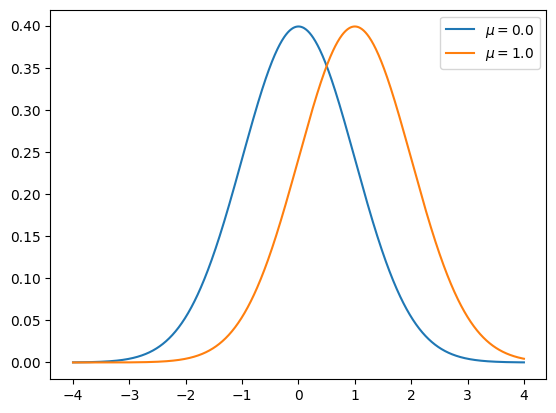

In [2]:
# New axes.
fig, ax = plt.subplots()

# X values.
x = np.linspace(-4.0, 4.0, 1000)

# Two normal distributions.
ax.plot(x, stats.norm.pdf(x, 0.0, 1.0), label=r'$\mu = 0.0$')
ax.plot(x, stats.norm.pdf(x, 1.0, 1.0), label=r'$\mu = 1.0$')

ax.legend();

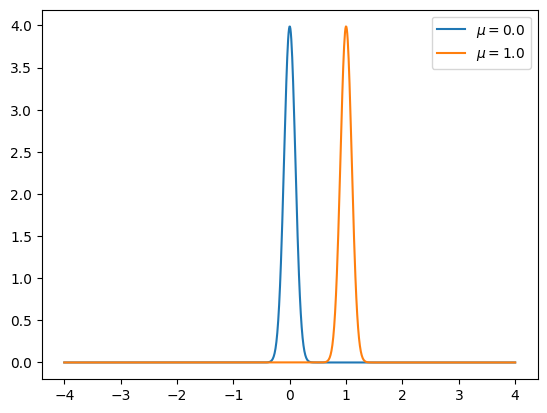

In [3]:
# New axes.
fig, ax = plt.subplots()

# X values.
x = np.linspace(-4.0, 4.0, 1000)

# Two normal distributions.
ax.plot(x, stats.norm.pdf(x, 0.0, 0.1), label=r'$\mu = 0.0$')
ax.plot(x, stats.norm.pdf(x, 1.0, 0.1), label=r'$\mu = 1.0$')

ax.legend();

## Normal Samples

[numpy.random.normal](https://numpy.org/doc/2.0/reference/random/generated/numpy.random.normal.html)



In [4]:
# Group A.
group_a = np.random.normal(5, 2, 30)

# Group B.
group_b = np.random.normal(6, 2, 30)

# Show.
group_a, group_b

(array([ 4.54065517,  6.62504714,  7.40039537,  2.82716096,  3.85377441,
         7.91180631,  8.42780745,  5.9319841 ,  5.60114131,  2.29312367,
         3.66087497,  4.93550236,  5.26676923,  7.16743975,  3.00897163,
         4.68038659,  3.67869222,  1.75977477,  7.79960757,  5.2005967 ,
         4.91197903,  8.70099028,  7.29299468,  4.48120068,  7.59867894,
        -0.38873947,  8.66469087,  5.02380924,  5.9620297 ,  3.46165632]),
 array([7.82476207, 5.23542615, 5.59799202, 4.54053853, 7.12775488,
        5.88996197, 7.84491293, 5.94600703, 9.61995854, 7.16484683,
        5.20040565, 3.4588193 , 7.29210352, 1.59284959, 9.718829  ,
        5.63750178, 3.75846423, 4.71009025, 8.7155479 , 7.88838287,
        5.96621072, 4.06163553, 5.78271227, 2.4426762 , 1.06995899,
        7.79905492, 6.77217172, 1.23739927, 6.32913213, 4.79154636]))

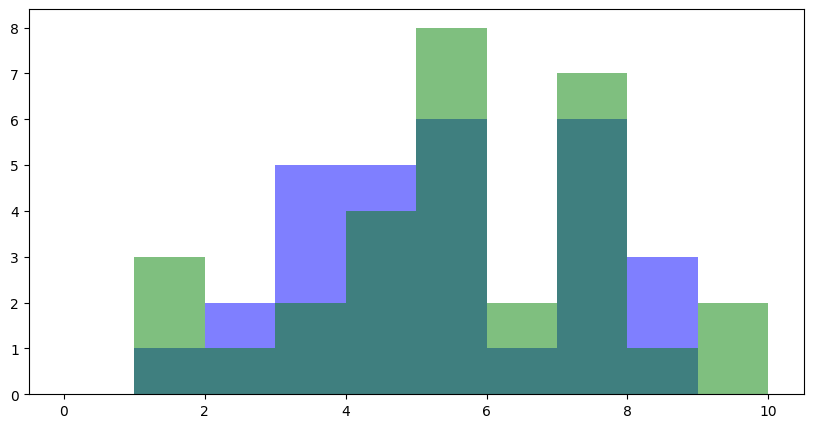

In [5]:
# Create an empty data frame.
fig, ax = plt.subplots(figsize=(10, 5))

# Create histogram.
ax.hist(group_a, bins=np.arange(11), color='blue', alpha=0.5, label='Group A')

# Create histogram.
ax.hist(group_b, bins=np.arange(11), color='green', alpha=0.5, label='Group B');

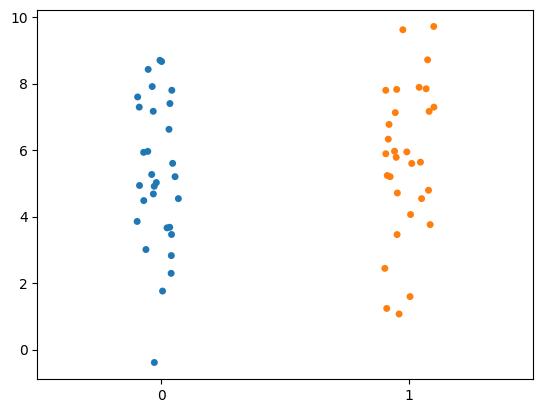

In [6]:
# Create a strip plot.
sns.stripplot(data=[group_a, group_b]);

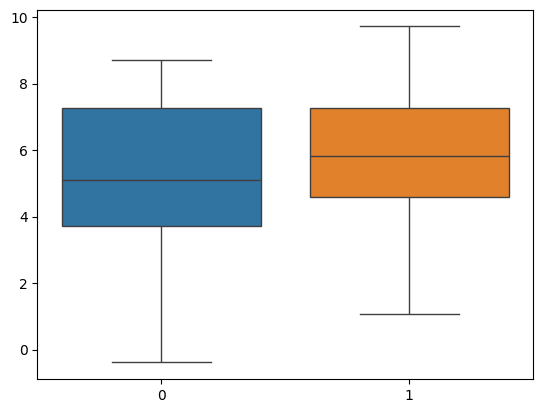

In [7]:
# Box plot.
sns.boxplot(data=[group_a, group_b]);

## Independent Samples $t$-Test

[scipy.stats.
ttest_ind](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html#ttest-ind)

**Null Hypothesis:** the population means are equal.

In [8]:
# Perform a t-test.
stats.ttest_ind(group_a, group_b)

TtestResult(statistic=np.float64(-0.7291693301638779), pvalue=np.float64(0.46883248044731873), df=np.float64(58.0))

## Significance

In [9]:
stats.t.ppf(0.025, df=58), stats.t.ppf(0.975, df=58)

(np.float64(-2.001717484145236), np.float64(2.0017174841452356))

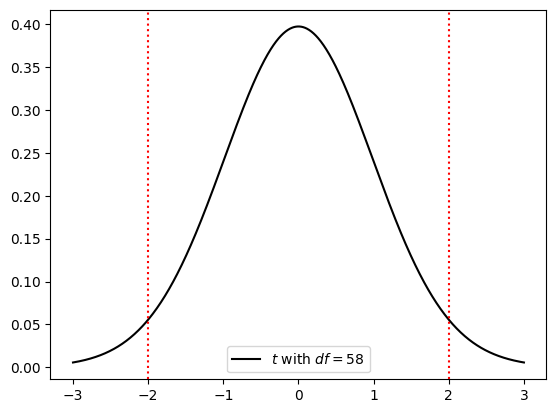

In [10]:
# Figure, axes.
fig, ax = plt.subplots()

# X values.
x = np.linspace(-3.0, 3.0, 1000)

# t distribution.
ax.plot(x, stats.t.pdf(x, df=58), 'k', label=r'$t$ with $df=58$')

# 0.05 cut offs.
ax.axvline(stats.t.ppf(0.025, df=58), color='r', linestyle=':')
ax.axvline(stats.t.ppf(0.975, df=58), color='r', linestyle=':')

# Legend.
ax.legend();

## One Sample $t$-Test

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_1samp.html

In [11]:
# A group of normally distributed values.
group_a = np.random.normal(5, 0.2, 30)

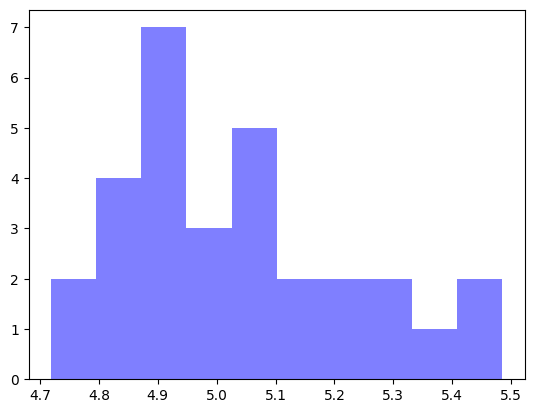

In [12]:
# Histgoram.
plt.hist(group_a, color='blue', alpha=0.5, label='Group A');

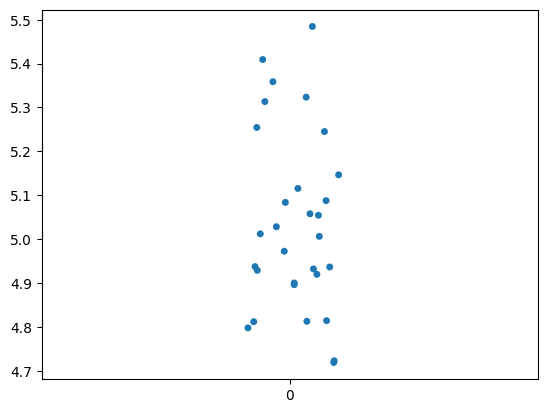

In [13]:
# Strip plot.
sns.stripplot(data=[group_a]);

In [14]:
# One sample test.
stats.ttest_1samp(group_a, 5)

TtestResult(statistic=np.float64(0.9616565037277567), pvalue=np.float64(0.34417253069380993), df=np.int64(29))

## Paired Samples $t$-Test

In [15]:
# A group of normally distributed values.
group_a = np.random.normal(5, 0.2, 30)

# Add normally distributed values.
group_b = group_a + np.random.normal(0.2, 0.1, 30)

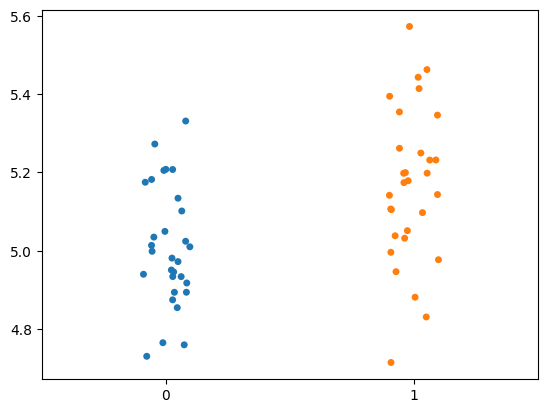

In [16]:
# Strip plot.
sns.stripplot(data=[group_a, group_b]);

### scipy.stats.ttest_rel

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_rel.html#ttest-rel

In [17]:
# Paired samples t-test.
stats.ttest_rel(group_a, group_b)

TtestResult(statistic=np.float64(-8.973997521402518), pvalue=np.float64(7.248668342425348e-10), df=np.int64(29))

In [18]:
# One sample test - same values.
stats.ttest_1samp(group_a - group_b, 0)

TtestResult(statistic=np.float64(-8.973997521402518), pvalue=np.float64(7.248668342425348e-10), df=np.int64(29))

## End